In [3]:
from google.colab import files
uploaded = files.upload()

Saving Vgsales.xlsx to Vgsales.xlsx


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_excel("Vgsales.xlsx")
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [27]:
df = df[['Genre', 'Global_Sales', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]

df = df.dropna()

In [28]:
# Remove rows where Global_Sales is 0 to avoid division issues
df = df[df['Global_Sales'] > 0].copy()

In [30]:
df['NA_ratio'] = df['NA_Sales'] / df['Global_Sales']
df['EU_ratio'] = df['EU_Sales'] / df['Global_Sales']
df['JP_ratio'] = df['JP_Sales'] / df['Global_Sales']
df['Other_ratio'] = df['Other_Sales'] / df['Global_Sales']

# Keep only the clustering features
features = df[['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']].copy()

# -----------------------------
# 3. Standardize the features
# -----------------------------
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

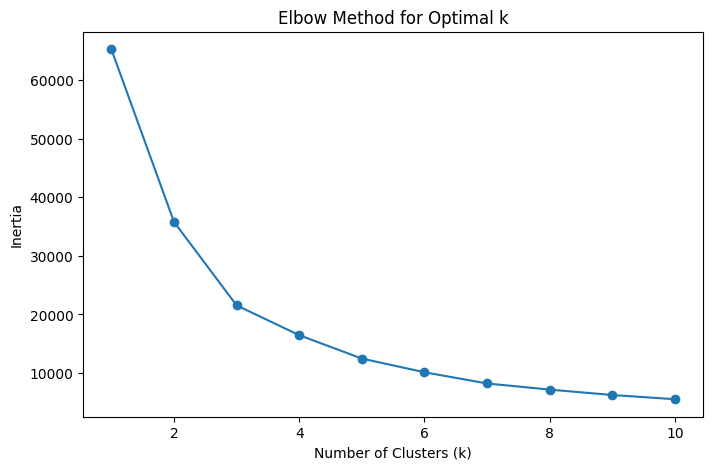

In [31]:
# -----------------------------
# 4. Elbow method
# -----------------------------
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [34]:
# ----------------------------------------
# 5. Fit final K-means model
# Choose k after inspecting elbow plot
# ----------------------------------------
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# -----------------------------
# 6. Cluster summary
# -----------------------------
cluster_summary = df.groupby('Cluster')[['NA_ratio', 'EU_ratio', 'JP_ratio', 'Other_ratio']].mean()
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         NA_ratio  EU_ratio  JP_ratio  Other_ratio
Cluster                                           
0        0.021060  0.010923  0.958578     0.008118
1        0.048909  0.818295  0.009654     0.102285
2        0.796274  0.120084  0.024933     0.041657
3        0.466999  0.365262  0.043406     0.125882


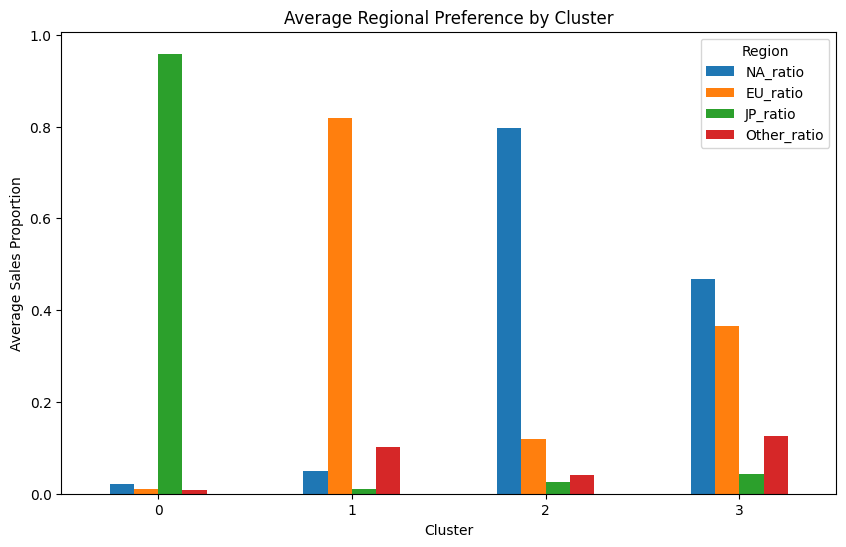

In [35]:
# -----------------------------
# 7. Bar chart of cluster means
# -----------------------------
cluster_summary.plot(kind='bar', figsize=(10, 6))
plt.title('Average Regional Preference by Cluster')
plt.ylabel('Average Sales Proportion')
plt.xticks(rotation=0)
plt.legend(title='Region')
plt.show()

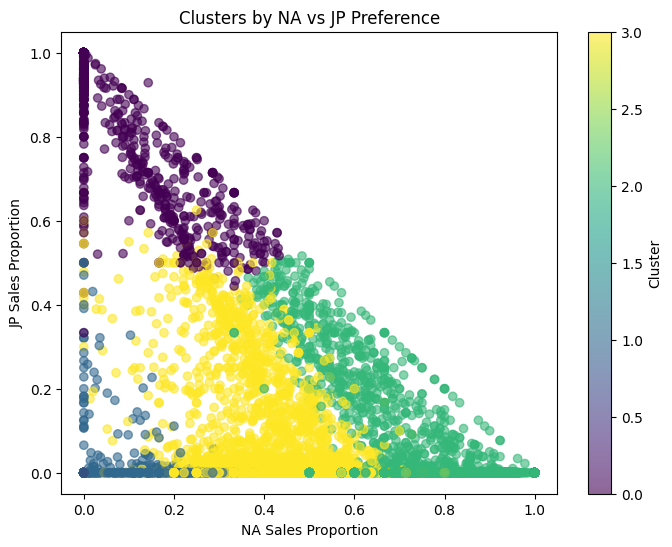

In [37]:
# -----------------------------
# 8. Scatter plot 1: NA vs JP
# -----------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['NA_ratio'],
    df['JP_ratio'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)
plt.xlabel('NA Sales Proportion')
plt.ylabel('JP Sales Proportion')
plt.title('Clusters by NA vs JP Preference')
plt.colorbar(scatter, label='Cluster')
plt.show()


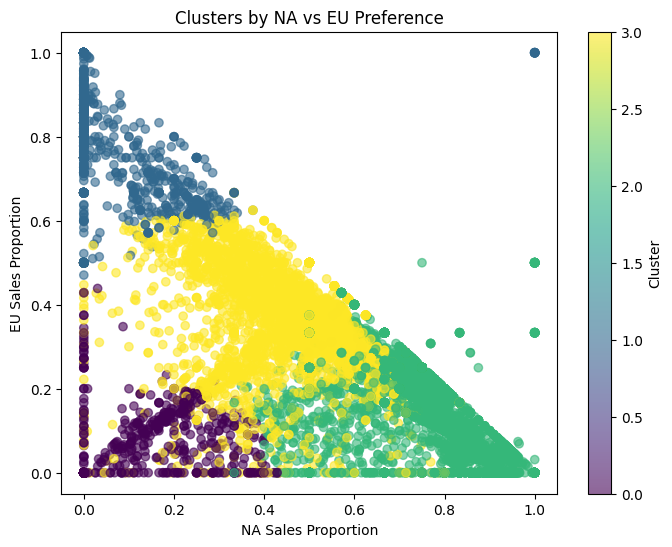

In [39]:
# -----------------------------
# 9. Scatter plot 2: NA vs EU
# -----------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['NA_ratio'],
    df['EU_ratio'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)
plt.xlabel('NA Sales Proportion')
plt.ylabel('EU Sales Proportion')
plt.title('Clusters by NA vs EU Preference')
plt.colorbar(scatter, label='Cluster')
plt.show()


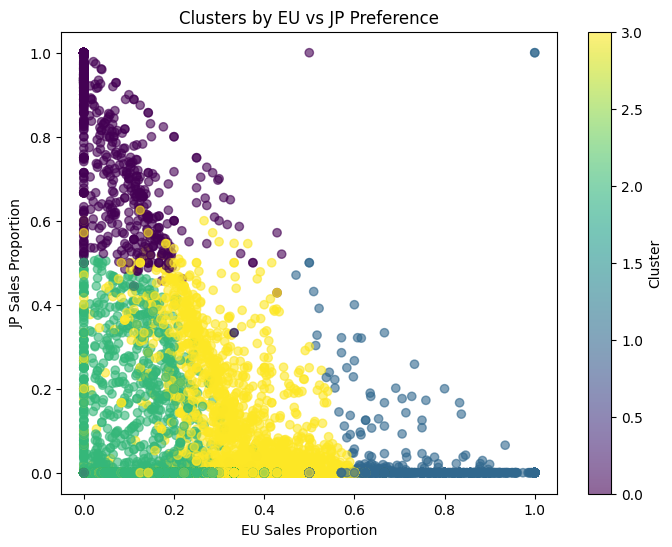

In [41]:
# -----------------------------
# 10. Scatter plot 3: EU vs JP
# -----------------------------
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df['EU_ratio'],
    df['JP_ratio'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6
)
plt.xlabel('EU Sales Proportion')
plt.ylabel('JP Sales Proportion')
plt.title('Clusters by EU vs JP Preference')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [43]:
# -----------------------------
# 11. Genre distribution by cluster
# -----------------------------
genre_cluster = df.groupby(['Cluster', 'Genre']).size().unstack(fill_value=0)
print("\nGenre Distribution by Cluster:")
print(genre_cluster)



Genre Distribution by Cluster:
Genre    Action  Adventure  Fighting  Misc  Platform  Puzzle  Racing  \
Cluster                                                                
0           614        664       275   426        79      93      64   
1           227        110        11   141        31      73     131   
2          1151        281       276   744       469     327     552   
3          1260        221       274   399       297      78     479   

Genre    Role-Playing  Shooter  Simulation  Sports  Strategy  
Cluster                                                       
0                 668       97         175     374       220  
1                  78      102         108     239       158  
2                 326      512         355    1076       158  
3                 397      571         212     615       135  


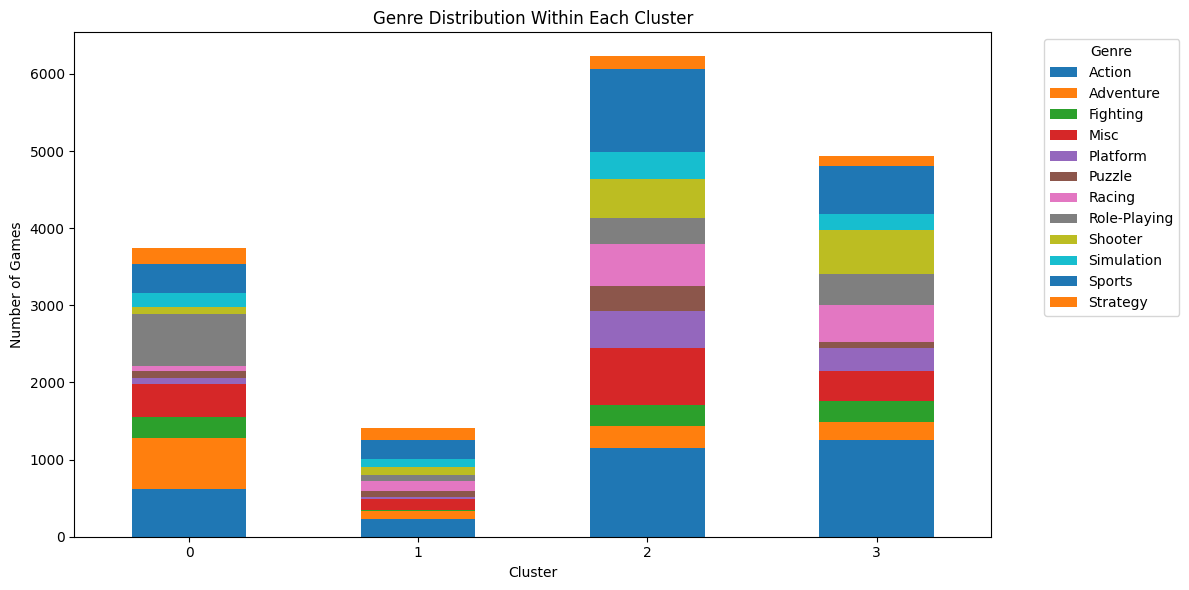

In [45]:
# -----------------------------
# 12. Stacked bar chart for genres
# -----------------------------
genre_cluster.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Genre Distribution Within Each Cluster')
plt.ylabel('Number of Games')
plt.xticks(rotation=0)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Cluster Sizes:
Cluster
0    3749
1    1409
2    6227
3    4938
Name: count, dtype: int64


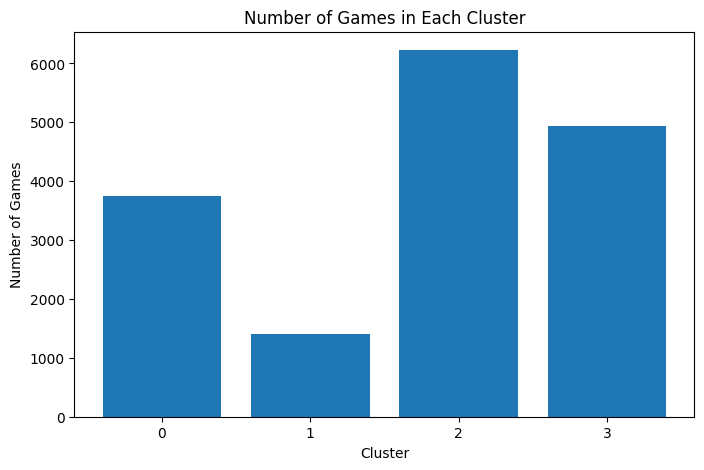

In [46]:
# -----------------------------
# 13. Cluster sizes
# -----------------------------
cluster_sizes = df['Cluster'].value_counts().sort_index()
print("\nCluster Sizes:")
print(cluster_sizes)

plt.figure(figsize=(8, 5))
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel('Cluster')
plt.ylabel('Number of Games')
plt.title('Number of Games in Each Cluster')
plt.show()